# Multi-Session LeJEPA Experiment Runner

Train and evaluate the LeJEPA teacher model on multi-session neural spike data.

**Order of operations:**
1. Set `CONFIG_PATH` in the Config cell.
2. Run all cells top to bottom.
3. Results (CSV + plots) are saved under `results_out_path` from your config.
4. Training curves, test metrics, and latent-space UMAP also render inline below.

**Prerequisite:** Run the dataset pipeline first (`experiments/data/create_dataset.py`) so a Parquet exists at your config's `data_path`.

Clone Repo

In [1]:
!git clone https://github.com/jacobposchl/jepsyn
!pip install snntorch temporaldata torch_brain umap-learn pyarrow pyyaml

Cloning into 'jepsyn'...
remote: Enumerating objects: 504, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 504 (delta 1), reused 3 (delta 1), pack-reused 499 (from 1)
Receiving objects: 100% (504/504), 48.92 MiB | 16.72 MiB/s, done.
Resolving deltas: 100% (221/221), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.6/125.6 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.9/65.9 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 68.8 MB/s eta 0:00:00
  Attempting uninstall: typeguard
    Found existing installation: typeguard 4.5.1
    Uninstalling typeguard-4.5.1:
      Successfully uninstalled typeguard-4.5.1
  Attempting uninstall: einops
    Found existing installation: einops 0.8.2
    Uninstalling einops-

In [2]:
import os
import sys
from pathlib import Path

# The repo is cloned to /content/jepsyn in Colab.
REPO_ROOT = Path("/content/jepsyn")
os.chdir(REPO_ROOT)
print(f"CWD: {Path.cwd()}")

# jepsyn/ package is importable directly from repo root.
# Add experiments/multi_session/ so multi_session.py can be imported by name.
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT / "experiments" / "multi_session"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

from multi_session import evaluate_model, load_and_prepare_data, save_results, train_lejepa
from jepsyn.utils import verify_config

print("Imports OK")

CWD: /content/jepsyn
Imports OK


## Configuration

Point `CONFIG_PATH` at your experiment YAML. See `configs/lejepa_lif_visual_cortex.yaml` for a full template with all encoder, predictor, and training fields.

At minimum, `results_out_path` must be set in the config for checkpoints and plots to be saved to disk.

In [3]:
# Path is relative to repo root (where you ran %cd jepsyn)
CONFIG_PATH = Path("experiments/multi_session/configs/lejepa_lif_visual_cortex.yaml")

config = verify_config(CONFIG_PATH)

print(f"Config loaded:      {CONFIG_PATH}")
print(f"data_path:          {config['data_path']}")
print(f"results_out_path:   {config.get('results_out_path', '(not set — results will not be saved to disk)')}")
print()
tcfg = config["training_config"]
mcfg = config["model_config"]
print(f"epochs:             {tcfg.get('epochs', 100)}")
print(f"batch_size:         {tcfg.get('batch_size', 32)}")
print(f"lr:                 {tcfg.get('lr', 1e-4)}")
print(f"mask_ratio:         {tcfg.get('mask_ratio', 0.5)}")
print(f"ema_momentum:       {tcfg.get('ema_momentum', 0.996)}")
print(f"lambd (SIGReg):     {tcfg.get('lambd', 0.05)}")
print()
print(f"d_model:            {mcfg.get('d_model', 256)}")
print(f"n_latents:          {mcfg.get('n_latents', 64)}")
print(f"max_time_ms:        {mcfg.get('max_time_ms', 400)}")

Config loaded:      experiments/multi_session/configs/lejepa_lif_visual_cortex.yaml
data_path:          /content/jepsyn/datasets/visp_visl_windows.parquet
results_out_path:   /content/jepsyn/results

epochs:             100
batch_size:         32
lr:                 0.0001
mask_ratio:         0.5
ema_momentum:       0.996
lambd (SIGReg):     0.05

d_model:            256
n_latents:          64
max_time_ms:        400


## Data Loading

Loads the Parquet from `data_path`, validates schema and integrity, then splits windows by `session_id` into train / val / test sets.

In [4]:
train_loader, val_loader, test_loader, unit_maps = load_and_prepare_data(config)

print(f"\nSessions in unit_maps: {len(unit_maps)}")
print(f"Units per session:     min={min(len(m) for m in unit_maps.values())}, "
      f"max={max(len(m) for m in unit_maps.values())}")
print(f"Train batches:         {len(train_loader)}")
print(f"Val batches:           {len(val_loader)}")
print(f"Test batches:          {len(test_loader)}")

Validating dataset integrity...
Passed basic validation checks.
Built unit maps for 48 sessions (sizes: [228, 136, 142, 186, 233, 145, 114, 185, 160, 152, 190, 131, 238, 209, 193, 150, 142, 173, 207, 222, 158, 218, 204, 146, 157, 185, 166, 264, 246, 147, 181, 93, 134, 224, 172, 174, 242, 175, 214, 187, 225, 129, 254, 204, 174, 174, 189, 189])
Train: 7505 windows (32 sessions)
Val:   1863 windows (8 sessions)
Test:  1892 windows (8 sessions)

Sessions in unit_maps: 48
Units per session:     min=93, max=264
Train batches:         235
Val batches:           59
Test batches:          60


## LeJEPA Training

Trains the **context encoder** (online, gradients flow), **target encoder** (EMA copy, no gradients), and **predictor** (narrow Transformer).

- Loss: `(1 - λ) * MSE(h_pred, h_tgt) + λ * SIGReg(h_ctx, h_tgt)`
- After training, the checkpoint is saved to `<results_out_path>/lejepa_checkpoint.pt`.

In [ ]:
!git pull
import importlib
import jepsyn.losses.lejepa
import jepsyn.losses
importlib.reload(jepsyn.losses.lejepa)
importlib.reload(jepsyn.losses)


In [5]:
jepa_model, jepa_train_metrics = train_lejepa(config, train_loader, val_loader, unit_maps)
print("\nTraining complete.")
jepa_train_metrics.tail()

Training on cuda


/content/jepsyn/jepsyn/models/encoder.py:100: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.self_attn_blocks = nn.TransformerEncoder(
/content/jepsyn/jepsyn/models/predictor.py:50: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(


Epoch   0 | train=0.0288 | val=0.0241 | pred=0.0061 (20.0%) | reg=0.4613 (80.0%)
Epoch   1 | train=0.0233 | val=0.0223 | pred=0.0028 (11.3%) | reg=0.4126 (88.7%)
Epoch   2 | train=0.0219 | val=0.0221 | pred=0.0022 (9.7%) | reg=0.3947 (90.3%)
Epoch   3 | train=0.0183 | val=0.0240 | pred=0.0034 (17.9%) | reg=0.2995 (82.1%)
Epoch   4 | train=0.0157 | val=0.0322 | pred=0.0064 (38.7%) | reg=0.1929 (61.3%)
Epoch   5 | train=0.0156 | val=0.0441 | pred=0.0099 (60.1%) | reg=0.1243 (39.9%)
Epoch   6 | train=0.0155 | val=0.0615 | pred=0.0112 (68.8%) | reg=0.0971 (31.2%)
Epoch   7 | train=0.0151 | val=0.0654 | pred=0.0114 (71.6%) | reg=0.0858 (28.4%)
Epoch   8 | train=0.0140 | val=0.0737 | pred=0.0105 (71.2%) | reg=0.0805 (28.8%)
Epoch   9 | train=0.0127 | val=0.0856 | pred=0.0094 (70.3%) | reg=0.0756 (29.7%)
Epoch  10 | train=0.0121 | val=0.0890 | pred=0.0089 (69.6%) | reg=0.0739 (30.4%)
Epoch  11 | train=0.0112 | val=0.0941 | pred=0.0080 (68.0%) | reg=0.0719 (32.0%)
Epoch  12 | train=0.0103 | va

,epoch,train_loss,train_pred_loss,train_reg_loss,val_loss
95,95,0.011028,0.008979,0.049954,0.112665
96,96,0.010848,0.008790,0.049949,0.114302
97,97,0.010584,0.008497,0.050236,0.118711
98,98,0.011627,0.009581,0.050498,0.128765
99,99,0.011374,0.009294,0.050892,0.125842


## Training Results

Saves `metrics.csv` and `training_curves.png` to `<results_out_path>/LeJEPA/training/`, then renders the curves inline.

In [6]:
save_results(stage="LeJEPA", phase="training", metrics=jepa_train_metrics, config=config)

Saved metrics to /content/jepsyn/results/LeJEPA/training/metrics.csv
Saved training curves to /content/jepsyn/results/LeJEPA/training/training_curves.png


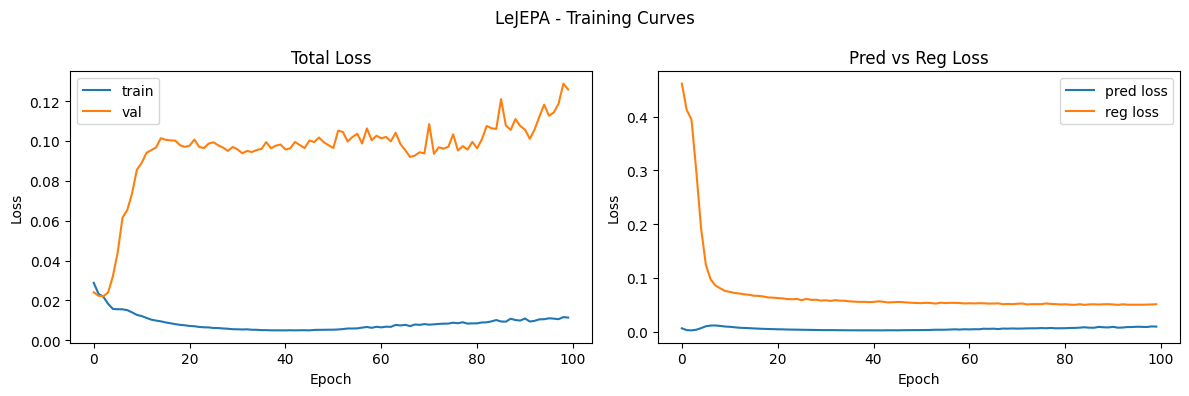

In [7]:
# Inline training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("LeJEPA - Training Curves")

axes[0].plot(jepa_train_metrics["epoch"], jepa_train_metrics["train_loss"], label="train")
axes[0].plot(jepa_train_metrics["epoch"], jepa_train_metrics["val_loss"], label="val")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Total Loss")
axes[0].legend()

axes[1].plot(jepa_train_metrics["epoch"], jepa_train_metrics["train_pred_loss"], label="pred loss")
axes[1].plot(jepa_train_metrics["epoch"], jepa_train_metrics["train_reg_loss"], label="reg loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("Pred vs Reg Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

In [8]:
# Full per-epoch metrics table
jepa_train_metrics

,epoch,train_loss,train_pred_loss,train_reg_loss,val_loss
0,0,0.028829,0.006066,0.461330,0.024070
1,1,0.023262,0.002769,0.412617,0.022313
2,2,0.021851,0.002229,0.394678,0.022087
3,3,0.018251,0.003447,0.299540,0.023995
4,4,0.015730,0.006403,0.192937,0.032187
...,...,...,...,...,...
95,95,0.011028,0.008979,0.049954,0.112665
96,96,0.010848,0.008790,0.049949,0.114302
97,97,0.010584,0.008497,0.050236,0.118711
98,98,0.011627,0.009581,0.050498,0.128765


## LeJEPA Test Evaluation

Runs the trained model on the held-out test set (no masking — context encoder sees all events).

Metrics per batch:
- **`pred_loss`**: MSE between predicted and target mean-pooled representations `[B, D]`
- **`cos_similarity`**: cosine similarity between context and target representations

In [9]:
jepa_test_metrics = evaluate_model(jepa_model, test_loader, stage="LeJEPA")


[LeJEPA] Evaluation Metrics:
pred_loss         0.031768
cos_similarity    0.979677


Saved metrics to /content/jepsyn/results/LeJEPA/test/metrics.csv
Saved test metrics to /content/jepsyn/results/LeJEPA/test/test_metrics.png


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved latent space plot to /content/jepsyn/results/LeJEPA/test/latent_space.png
Test metrics bar chart:


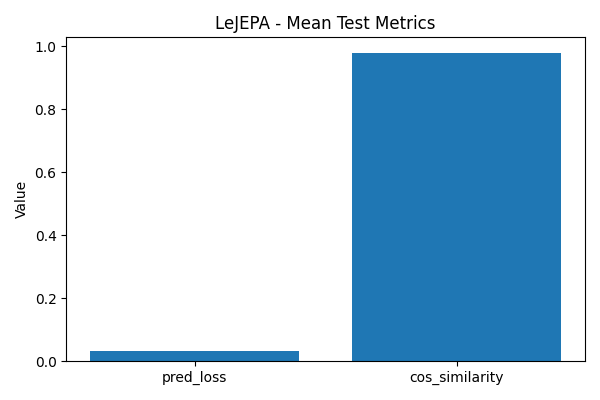

Latent space (UMAP):


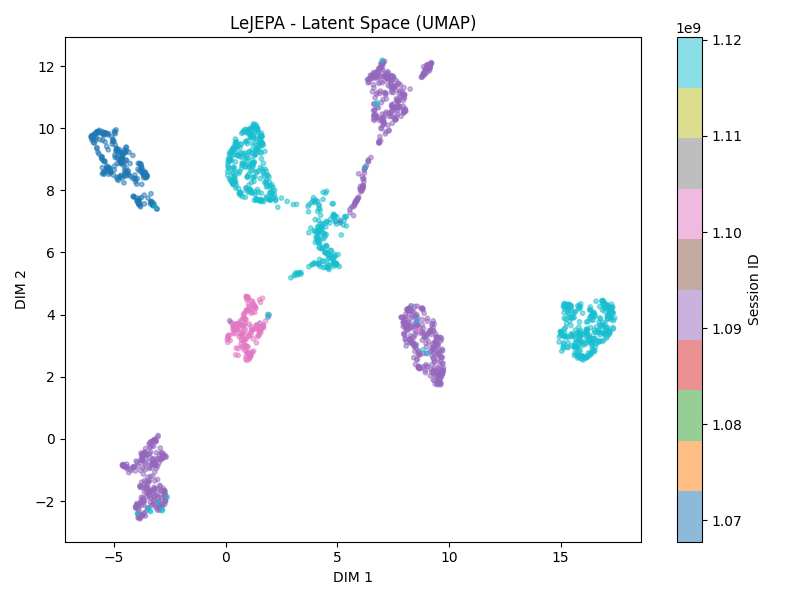

In [10]:
save_results(stage="LeJEPA", phase="test", metrics=jepa_test_metrics, config=config)

# Display saved plots if results_out_path is set
results_path = config.get("results_out_path")
if results_path:
    test_bar_path = Path(results_path) / "LeJEPA" / "test" / "test_metrics.png"
    latent_path   = Path(results_path) / "LeJEPA" / "test" / "latent_space.png"
    if test_bar_path.exists():
        print("Test metrics bar chart:")
        display(Image(filename=str(test_bar_path)))
    if latent_path.exists():
        print("Latent space (UMAP):")
        display(Image(filename=str(latent_path)))

## Download Results

In [12]:
!zip -r LeJEPA_export.zip results
from google.colab import files
files.download('results.zip')

  adding: results/LeJEPA/ (stored 0%)
  adding: results/LeJEPA/training/ (stored 0%)
  adding: results/LeJEPA/training/metrics.csv (deflated 52%)
  adding: results/LeJEPA/training/training_curves.png (deflated 8%)
  adding: results/LeJEPA/test/ (stored 0%)
  adding: results/LeJEPA/test/latent_space.png (deflated 3%)
  adding: results/LeJEPA/test/metrics.csv (deflated 57%)
  adding: results/LeJEPA/test/test_metrics.png (deflated 19%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>